In [6]:
import pandas as pd
import shap
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE

# Load dataset
df = pd.read_csv('../data/processed/cleaned_transactions.csv')

# Features and target
X = df.drop('Class', axis=1)
y = df['Class']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# SMOTE
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

# Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=50,
    random_state=42
)

rf_model.fit(X_train_smote, y_train_smote)

print("Model ready for SHAP!")

/Users/rouman/Desktop/Fraud_Detection/venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Model ready for SHAP!


In [7]:
import shap
import matplotlib.pyplot as plt

# Use only small sample
X_sample = X_test_scaled[:200]

# Create explainer
explainer = shap.TreeExplainer(rf_model)

# Generate SHAP values
shap_values = explainer.shap_values(X_sample)

print("SHAP values generated!")

SHAP values generated!


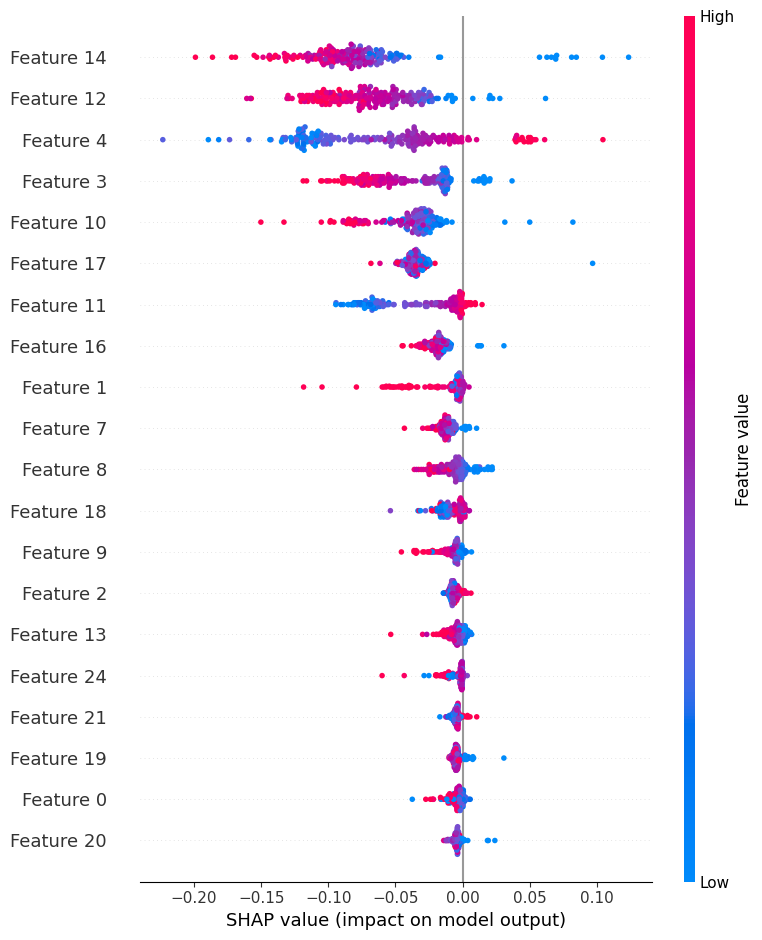

In [8]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_sample,
    show=False
)

plt.savefig(
    '../reports/figures/shap_summary.png',
    bbox_inches='tight'
)

plt.show()

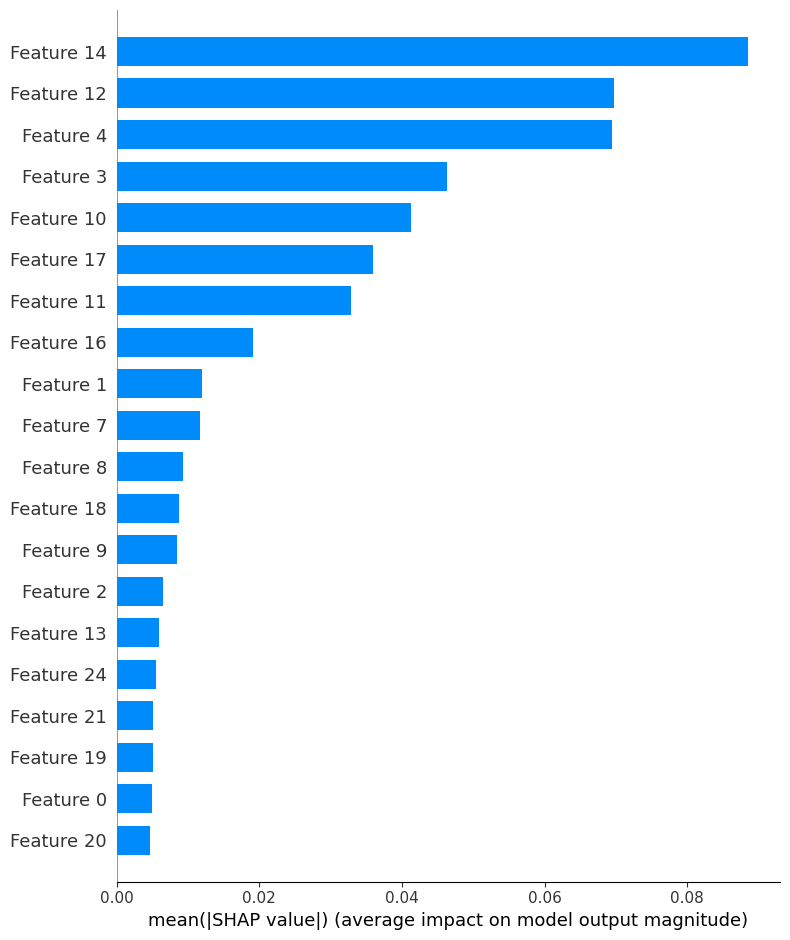

In [9]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_test_scaled,
    plot_type='bar',
    show=False
)

plt.savefig(
    '../reports/figures/shap_bar_plot.png',
    bbox_inches='tight'
)

plt.show()